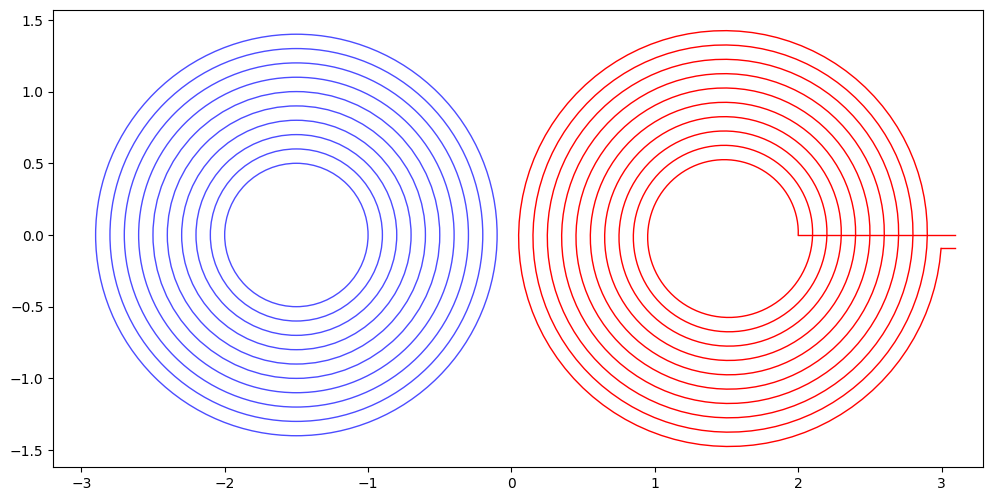

In [1]:
'''
Optimization of magnetic configuration created by two spirals.
'''
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.lines as lines
from dataclasses import dataclass
from scipy.optimize import minimize
import scipy.integrate as integrate
from itertools import combinations
import numpy as np


def spiral_demo():
    '''
    A spiral is modeled by a family of concentric circles.  This
    looks good, because the mean radial current due to the converging
    spiral is compensated by the outgoing straight wire in the opposite
    direction.
    '''
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    for i in range(10):
        ax.add_patch(Circle((-1.5, 0), 0.5+0.1*i, lw=1, alpha=0.7, facecolor='none', edgecolor='blue'))
    tt = np.linspace(0, 20*np.pi, 1000, endpoint=False)
    rr = 0.5 + 1.0*tt/(20*np.pi)
    xx = 1.5 + rr*np.cos(tt)
    yy = 0.0 + rr*np.sin(tt)
    ax.plot(xx, yy, color='red', lw=1)
    ax.add_artist(lines.Line2D([xx[0], xx[-1]+0.1], [yy[0], 0], linewidth=1, color='red'))
    ax.add_artist(lines.Line2D([xx[-1], xx[-1]+0.1], [yy[-1], yy[-1]], linewidth=1, color='red'))
    ax.set_aspect('equal')

spiral_demo()

In [9]:
@dataclass
class Spirals:
    x1: float = -1
    shift: float =  1.0 # x2 - x1
    z1: float = -0.01   # z-height of the spiral
    z2: float = -0.02
    a1: float =  0.2    # min radius
    a2: float =  0.3
    b1: float =  1.0    # max radius
    b2: float =  2.0
    Ir: float = -1.0 # I2/I1
    n1: int   = 10
    n2: int   = 10
    # maybe: excentricities (gradual shifts of centers along x)
    def x2(self): return self.x1 + self.shift
    def r1(self, i: int): return self.a1 + (self.b1 - self.a1)*i/(self.n1 - 1)
    def r2(self, i: int): return self.a2 + (self.b2 - self.a2)*i/(self.n2 - 1)
    def __str__(self): # make Params object printable
        n = 4 # precision
        return \
        f'x({round(self.x1,n)},{round(self.x2(),n)}), ' + \
        f'z({round(self.z1,n)},{round(self.z2,n)}), ' + \
        f'a({round(self.a1,n)},{round(self.a2,n)}), ' + \
        f'b({round(self.b1,n)},{round(self.b2,n)}), ' + \
        f'n({self.n1},{self.n2}), ' + \
        f'Ir{round(self.Ir,n)}'

@dataclass
class SpiralBounds:
    x1 = (-3, 3)
    shift = (0.05, 3)
    a1 = (0.2, 1)
    a2 = (0.2, 1)
    b1 = (1, 3)
    b2 = (1, 3)
    Ir = (-1, -0.1) # secoind loop current is smaller than first
    # z1,z2,n1,n2 fixed

def dB(x, y, z, a, t):
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D3 = D2*np.sqrt(D2)
    bx = a*z*cos/D3
    by = a*z*sin/D3
    bz = a*(a - x*cos - y*sin)/D3
    return np.array([bx, by, bz])

def dB_derivs(x, y, z, a, t):
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D1 = np.sqrt(D2)
    D3 = D2*D1
    D5 = D2*D3
    bxx = -3*a*z*cos*(x - a*cos)/D5
    bxz = a*cos/D3*(1 - 3*z*z/D2)
    bzx = -a*cos/D3 - 3*a*(x - a*cos)*(a - x*cos - y*sin)/D5
    bzz = 3*a*z*(x*cos + y*sin - a)/D5
    return np.array([bxx, bxz, bzx, bzz]) # only some of them

def loop_B(x, y, z, a):
    return integrate.quad_vec(lambda t: dB(x, y, z, a, t), 0, 2*np.pi)[0]

def loop_B_derivs(x, y, z, a):
    return integrate.quad_vec(lambda t: dB_derivs(x, y, z, a, t), 0, 2*np.pi)[0]

def add_to(lhs, rhs):
    return rhs if lhs is None else lhs + rhs

def total_B(x, y, z, spirals): # (Bx, By, Bz)
    B1, B2 = None, None
    for i in range(spirals.n1): B1=add_to(B1, loop_B(x - spirals.x1, y, z - spirals.z1, spirals.r1(i)))
    for i in range(spirals.n2): B2=add_to(B2, loop_B(x - spirals.x2(), y, z - spirals.z2, spirals.r2(i)))
    Bx = B1[0] + spirals.Ir*B2[0]
    By = B1[1] + spirals.Ir*B2[1]
    Bz = B1[2] + spirals.Ir*B2[2]
    return np.array([Bx, By, Bz])

def total_B_derivs(x, y, z, spirals):
    D1, D2 = None, None
    for i in range(spirals.n1): D1=add_to(D1, loop_B_derivs(x - spirals.x1, y, z - spirals.z1, spirals.r1(i)))
    for i in range(spirals.n2): D2=add_to(D2, loop_B_derivs(x - spirals.x2(), y, z - spirals.z2, spirals.r2(i)))
    return D1 + spirals.Ir*D2 # (Bxx, Bxz, Bzx, Bzz)

def compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz):
    C = Bzz - Bxx
    D = np.sqrt(C*C + 4*Bxz*Bzx)
    evec = (C + D, 2*Bxz) # the other one is (C - D, 2*Bxz)
    return evec

def mark_spiral(ax, x, z, a, b, n, color):
    for i in range(n):
        r = a + i*(b-a)/(n-1)
        ax.add_patch(Circle((x-r, z), 0.04, color=color, alpha=0.7))
        ax.add_patch(Circle((x+r, z), r, color=color, alpha=0.7))
    ax.add_artist(lines.Line2D([x-b, x+b], [z, z], linewidth=1, color=color))

def mark_x(ax, evec):
    if 0: # small marker
        ax.scatter(null_x, null_z, s=50, color='brown', marker='X')
    R = 0.5 # wheel radius
    lw = 0.3
    theta = np.atan2(evec[0], evec[1])
    for i in range(4):
        ax.add_artist(lines.Line2D([null_x, null_x + R*np.cos(theta+i*np.pi/2)],
                                   [null_z, null_z + R*np.sin(theta+i*np.pi/2)],
                                   linewidth=lw, color='blue'))
    ax.add_patch(Circle((null_x, null_z), R, fill=False, color='blue', linewidth=lw))
    #print(f'theta={theta}') # theta=[0.22812388]
    theta = theta[0]
    if theta > np.pi/2:
        theta -= np.pi/2
    return theta*180/np.pi

def plot_field(spirals, null_x, null_z, title):
    focus_on_x = False # draw only in the vicinity of the X-point
    if focus_on_x:
        xmin, xmax = -1, 1
        zmin, zmax =  0.5, 2.5
    else:
        xmin, xmax = -4, 4
        zmin, zmax =  0.1, 3
    xx, zz = np.linspace(xmin, xmax, 150), np.linspace(zmin, zmax, 150)
    xx_grid, zz_grid = np.meshgrid(xx, zz)
    B = total_B(xx_grid, 0, zz_grid, pp)
    # print(B)
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    if 1:
        mark_spiral(ax, pp.x1, pp.z1, pp.a1, pp.b1, pp.n1, 'blue')
        mark_spiral(ax, pp.x2(), pp.z2, pp.a2, pp.b2, pp.n2, 'red')
        Bxx, Bxz, Bzx, Bzz = total_B_derivs(null_x, null_y, null_z, pp)
        evec = compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz)
        deg = mark_x(ax, evec)
    ax.streamplot(xx_grid, zz_grid, B[0], B[2], density=2, color='g',
                    linewidth=0.5, cmap=plt.cm.viridis, arrowsize=0.8)
    ax.set_aspect('equal')
    ax.set_title(f'{title}: {round(deg, 2)} deg')
    plt.show()

def search_params(null_x, null_y, null_z, vars):
    pp = Spirals()  # default/initial params
    bb = SpiralBounds()
    def angle_utility(evec):
        angle = np.atan2(evec[0], evec[1]) # in [-pi, pi]
        if angle < 0:
            angle += np.pi
        if angle > np.pi/2:
            angle -= np.pi/2
        deg = angle*180/np.pi # in [0, 90]
        return ((deg - 36)*(deg - 56)/8100)**2
    def utility(values):
        for var, value in zip(vars, values):
            setattr(pp, var, value) # set pp.<var> = value
        B = total_B(null_x, null_y, null_z, pp)
        field_utility = np.sum(np.square(B))
        Bxx, Bxz, Bzx, Bzz = total_B_derivs(null_x, null_y, null_z, pp)
        evec = compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz)
        return field_utility + angle_utility(evec)
    initial_values = [getattr(pp, var) for var in vars]
    bounds         = [getattr(bb, var) for var in vars]
    result = minimize(utility, initial_values, bounds=bounds)
    return result

null_x, null_y, null_z = np.array([0.0]), np.array([0.0]), np.array([1.5])

def optimize_over_spiral_combinations(dim):
    vars_tuples = list(combinations(['x1', 'shift', 'a1', 'a2', 'b1', 'b2', 'Ir'], dim))
    results = [] # for each vars_tuple
    for idx, vars in enumerate(vars_tuples):
        result = search_params(null_x, null_y, null_z, vars)
        results.append(result)
        print(f'Run {idx:02d}:  {vars} -> {result.x}: U -> {result.fun}')
    return vars_tuples, results

dim = 6
vars_tuples, results = optimize_over_spiral_combinations(dim)

Run 00:  ('x1', 'shift', 'a1', 'a2', 'b1', 'b2') -> [3.         0.05       0.20000549 0.2        1.33605425 1.37265043]: U -> 5.8211990086004416e-05
Run 01:  ('x1', 'shift', 'a1', 'a2', 'b1', 'Ir') -> [ 3.          0.38200943  0.2         0.20039172  1.         -0.35115741]: U -> 0.00015987016138885332
Run 02:  ('x1', 'shift', 'a1', 'a2', 'b2', 'Ir') -> [ 3.          0.05        0.2         0.37277968  1.14324231 -0.6969228 ]: U -> 1.0166945186173887e-05
Run 03:  ('x1', 'shift', 'a1', 'b1', 'b2', 'Ir') -> [ 3.          0.08195678  0.2         1.00527466  1.25882895 -0.64958581]: U -> 1.7057875632531e-05
Run 04:  ('x1', 'shift', 'a2', 'b1', 'b2', 'Ir') -> [ 3.          0.07795773  0.21503279  1.01543764  1.25559031 -0.71044293]: U -> 1.723914007026762e-05
Run 05:  ('x1', 'a1', 'a2', 'b1', 'b2', 'Ir') -> [ 3.          0.2         1.          1.          2.52342411 -0.26012726]: U -> 0.004078758020718273
Run 06:  ('shift', 'a1', 'a2', 'b1', 'b2', 'Ir') -> [ 0.07991377  0.2         0.42988

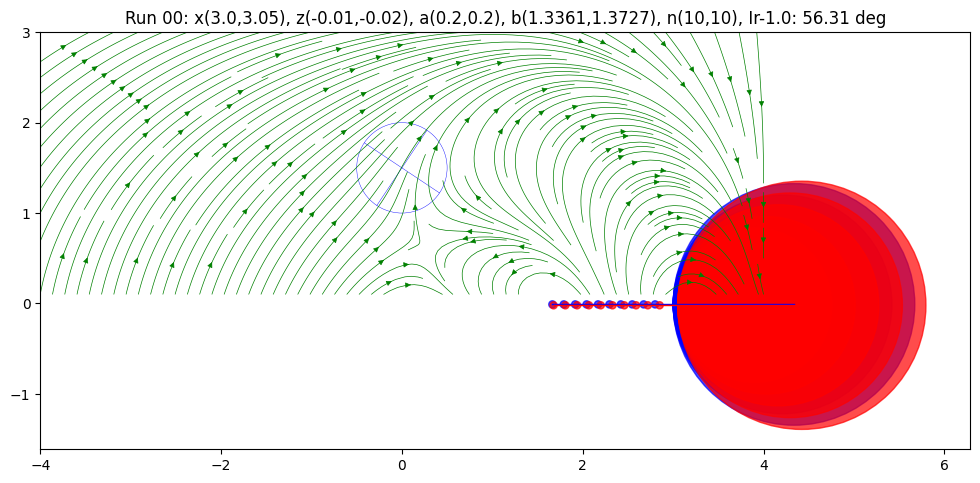

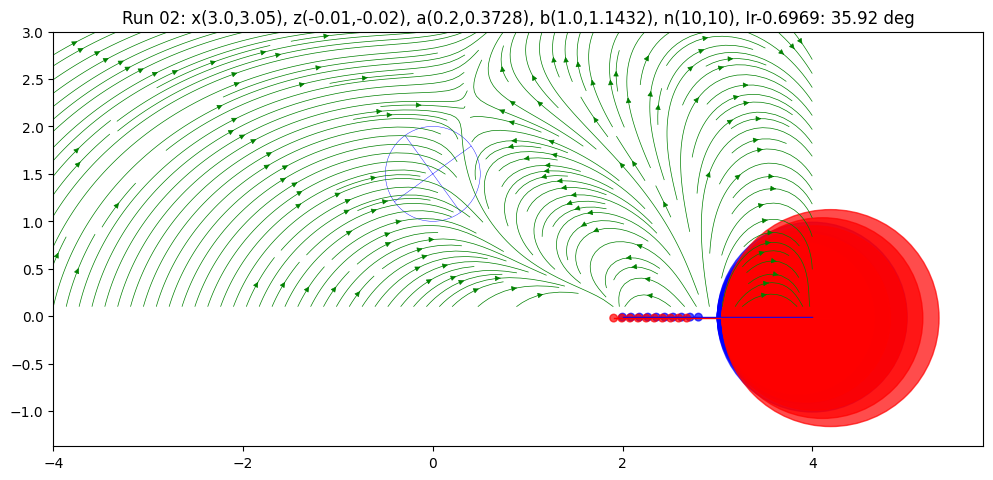

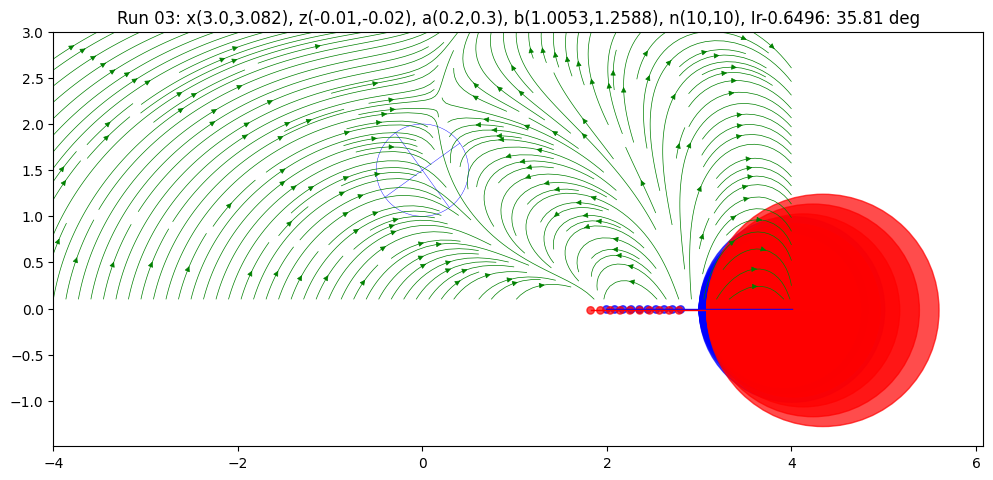

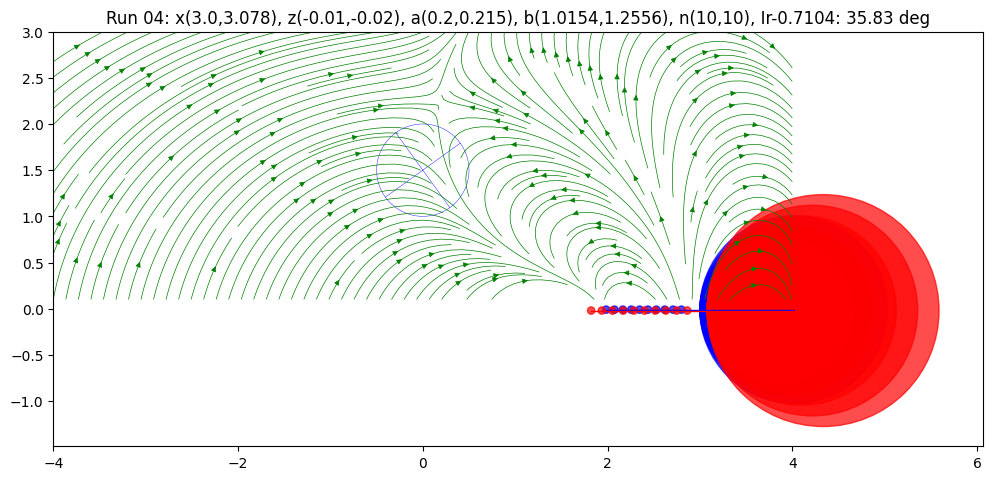

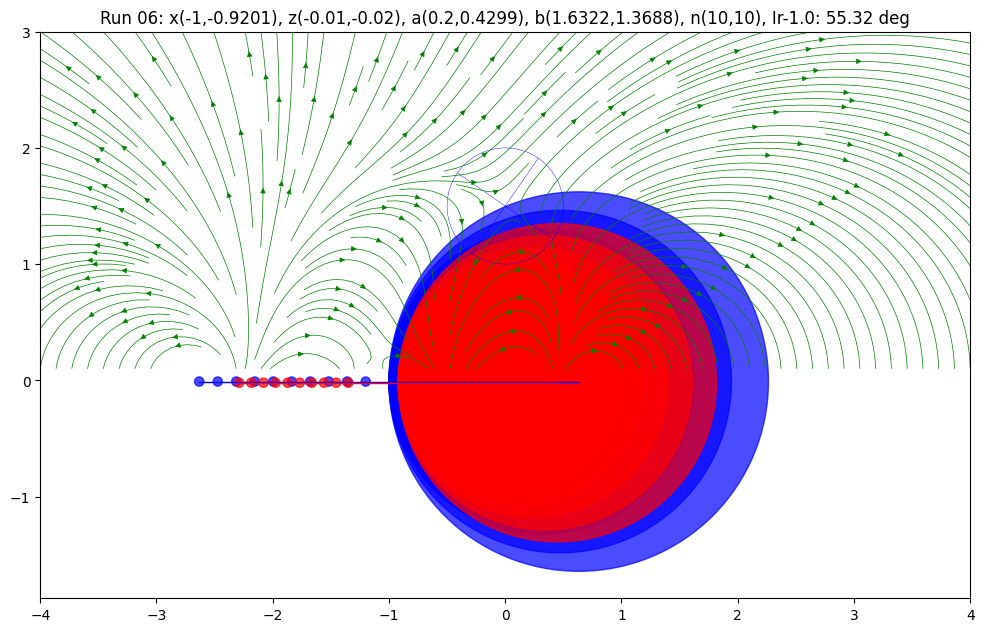

In [10]:
for idx, (vars, result) in enumerate(zip(vars_tuples, results)):
    if result.fun > 1e-4:
        continue
    pp = Spirals()
    for var, value in zip(vars, result.x):
        setattr(pp, var, value) # set pp.<var> = to best values saved in result.x
    title = f'Run {idx:02d}: {pp}'
    plot_field(pp, null_x, null_z, title)